**Import the dataset and libraries**

In [178]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data (2).csv


In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

**Preview First 5 Rows**

In [180]:
df = pd.read_csv("data.csv")
print(df.head(5)) #Preview first 5 rows

   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ETA_dEpsilon_C  MDEO-22     Class  
0      

**Statistical Summary**

In [181]:
print(df.describe())

           MATS3v    nHBint10      MATS3s      MATS3p  nHBDon_Lipinski  \
count  171.000000  171.000000  171.000000  171.000000       171.000000   
mean    -0.031244    0.315789   -0.001001   -0.061501         0.994152   
std      0.063559    0.762918    0.063928    0.072891         1.108773   
min     -0.311500    0.000000   -0.184600   -0.348500         0.000000   
25%     -0.066700    0.000000   -0.036000   -0.099550         0.000000   
50%     -0.032500    0.000000   -0.002000   -0.059400         1.000000   
75%      0.004850    0.000000    0.029000   -0.017100         2.000000   
max      0.141100    4.000000    0.218100    0.129000         6.000000   

        minHBint8      MATS3e      MATS3c   minHBint2      MATS3m  ...  \
count  171.000000  171.000000  171.000000  171.000000  171.000000  ...   
mean     0.677770   -0.025418   -0.053289    1.569251    0.003226  ...   
std      1.647322    0.078645    0.109463    2.497362    0.074076  ...   
min      0.000000   -0.211900   -0.47

**Shape of the dataset**

In [182]:
print("Dataset shape:", df.shape)

Dataset shape: (171, 1204)


**Info and Datatypes**

In [183]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Columns: 1204 entries, MATS3v to Class
dtypes: float64(1003), int64(200), object(1)
memory usage: 1.6+ MB
None


**Check Missing Values**

In [184]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 MATS3v             0
nHBint10           0
MATS3s             0
MATS3p             0
nHBDon_Lipinski    0
                  ..
nT5Ring            0
SHdNH              0
ETA_dEpsilon_C     0
MDEO-22            0
Class              0
Length: 1204, dtype: int64


**Target Distribution**

Class
NonToxic    115
Toxic        56
Name: count, dtype: int64


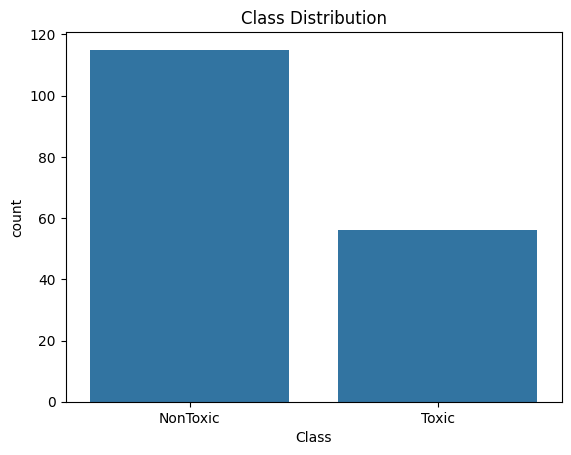

In [185]:
print(df['Class'].value_counts())
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

**Separate Features and Targets**

In [186]:
X = df.drop("Class", axis=1)
y = df["Class"]

**Encode Targets**

In [187]:
le = LabelEncoder()
y = le.fit_transform(y)

**Remove Constant Features**

In [188]:
constant_filter = VarianceThreshold(threshold=0)
X = constant_filter.fit_transform(X)
print("Shape after removing constant features:", X.shape)

Shape after removing constant features: (171, 1203)


**Scale Features**

In [189]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

**Define the pipeline**

In [190]:
pipeline = Pipeline([
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("model", RandomForestClassifier(class_weight='balanced',random_state=42))
])

**Hyperparameter Grid**

In [191]:
param_grid = {
    'feature_selection__k': [20, 50, 100],  # Number of features to select
    'model__n_estimators': [100, 200],      # Random Forest estimators
    'model__max_depth': [None, 10, 20]      # Max depth of trees
}

**Nested Cross-validation**
*   Outer loop: Performance evaluation on unseen data
*   Inner loop: Hyperparameter tuning/Model Selection

In [192]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

outer_scores = []

for train_idx, test_idx in outer_cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # GridSearchCV for inner loop
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='accuracy',
        n_jobs=-1
    )

In [193]:
    grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('feature_selection', SelectKBest()),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'feature_selection__k': [20, 50, 100],
                         'model__max_depth': [None, 10, 20],
                         'model__n_estimators': [100, 200]},
             scoring='accuracy')

In [194]:
    best_model = grid.best_estimator_


**Evaluation**

In [195]:
    y_pred = best_model.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    outer_scores.append(score)

In [196]:
    print("Fold Accuracy:", score)
    print("Best parameters:", grid.best_params_)
    print(classification_report(y_test, y_pred, target_names=le.classes_))

Fold Accuracy: 0.5882352941176471
Best parameters: {'feature_selection__k': 50, 'model__max_depth': 10, 'model__n_estimators': 200}
              precision    recall  f1-score   support

    NonToxic       0.67      0.78      0.72        23
       Toxic       0.29      0.18      0.22        11

    accuracy                           0.59        34
   macro avg       0.48      0.48      0.47        34
weighted avg       0.54      0.59      0.56        34



In [197]:
print("======================================")
print("Nested CV Accuracy Scores:", outer_scores)
print("Mean Nested CV Accuracy:", np.mean(outer_scores))

Nested CV Accuracy Scores: [0.5882352941176471]
Mean Nested CV Accuracy: 0.5882352941176471
